# Oxford-IIIT Pet: Transfer Learning Experiment Notebook

This notebook performs a full image classification workflow on the Oxford-IIIT Pet dataset (37 breeds):

1. Reproducible setup and GPU checks
2. Data loading and split diagnostics
3. Data augmentation experiments
4. Transfer learning across multiple backbones
5. Fine-tuning top model
6. Learning curves, confusion matrix, classification report
7. Hardest class analysis and Grad-CAM on misclassifications

In [ ]:
# %pip install -q tensorflow-datasets seaborn scikit-learn opencv-python

In [16]:
import os
import time
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
import tensorflow_datasets as tfds

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Eager mode:', tf.executing_eagerly())

gpus = tf.config.list_physical_devices('GPU')
print('GPUs detected:', gpus)
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('GPU training is enabled (if CUDA runtime is properly configured).')
else:
    print('No GPU detected. Training will run on CPU and be significantly slower.')

AUTOTUNE = tf.data.AUTOTUNE

TensorFlow: 2.17.1
Eager mode: True
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU training is enabled (if CUDA runtime is properly configured).


## Configuration

Change this block first if you want a faster or deeper run.

In [17]:
# Presets: 'quick' or 'full'
RUN_PRESET = 'quick'

CONFIG = {
    'quick': {
        'image_size': 224,
        'batch_size': 32,
        'epochs_frozen': 12,
        'epochs_finetune': 10,
        'lr_frozen': 1e-3,
        'lr_finetune': 1e-5,
        'unfreeze_layers': 30,
    },
    'full': {
        'image_size': 224,
        'batch_size': 32,
        'epochs_frozen': 16,
        'epochs_finetune': 12,
        'lr_frozen': 8e-4,
        'lr_finetune': 8e-6,
        'unfreeze_layers': 60,
    }
}

BACKBONES = ['MobileNetV2', 'ResNet50', 'EfficientNetB0']
AUG_POLICIES = ['lite', 'strong']

cfg = CONFIG[RUN_PRESET]
print('Preset:', RUN_PRESET)
print(cfg)

artifacts_dir = Path('./models/oxford_pet_transfer')
artifacts_dir.mkdir(parents=True, exist_ok=True)

Preset: quick
{'image_size': 224, 'batch_size': 32, 'epochs_frozen': 12, 'epochs_finetune': 10, 'lr_frozen': 0.001, 'lr_finetune': 1e-05, 'unfreeze_layers': 30}


## Load Oxford-IIIT Pet and Build Splits

In [18]:
# Load raw JPEG bytes so we can decode with recovery options and skip broken files safely.
(ds_trainval_bytes, ds_test_bytes), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train', 'test'],
    as_supervised=False,
    with_info=True,
    shuffle_files=False,
    decoders={'image': tfds.decode.SkipDecoding()}
 )

class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes
print('Classes:', num_classes)
print('First 10 class names:', class_names[:10])

trainval_count = ds_info.splits['train'].num_examples
test_count = ds_info.splits['test'].num_examples
print('Trainval examples:', trainval_count)
print('Official test examples:', test_count)

train_count = int(0.8 * trainval_count)
val_count = trainval_count - train_count

def safe_decode(example):
    image = tf.io.decode_jpeg(
        example['image'],
        channels=3,
        try_recover_truncated=True,
        acceptable_fraction=0.3
    )
    image = tf.cast(image, tf.float32)
    label = tf.cast(example['label'], tf.int32)
    return image, label

ds_trainval_bytes = ds_trainval_bytes.shuffle(trainval_count, seed=SEED, reshuffle_each_iteration=False)
train_raw = ds_trainval_bytes.take(train_count)
val_raw = ds_trainval_bytes.skip(train_count).take(val_count)
test_raw = ds_test_bytes

# Decode once, skip broken samples, and cache clean samples so repeated epochs do not re-hit bad files.
train_raw = (
    train_raw
    .map(safe_decode, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .cache('./models/oxford_pet_transfer/train_decoded_cache')
)
val_raw = (
    val_raw
    .map(safe_decode, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .cache('./models/oxford_pet_transfer/val_decoded_cache')
)
test_raw = (
    test_raw
    .map(safe_decode, num_parallel_calls=AUTOTUNE)
    .apply(tf.data.experimental.ignore_errors())
    .cache('./models/oxford_pet_transfer/test_decoded_cache')
)

print('Split sizes -> train:', train_count, 'val:', val_count, 'test:', test_count)
print('JPEG recovery mode enabled. Corrupted files are skipped, then clean samples are cached.')

Classes: 37
First 10 class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair']
Trainval examples: 3680
Official test examples: 3669
Split sizes -> train: 2944 val: 736 test: 3669
JPEG recovery mode enabled. Corrupted files are skipped, then clean samples are cached.


In [19]:
def count_labels(ds, n_classes):
    counts = np.zeros(n_classes, dtype=np.int64)
    for _, y in tfds.as_numpy(ds):
        counts[int(y)] += 1
    return counts

train_counts = count_labels(train_raw, num_classes)
val_counts = count_labels(val_raw, num_classes)
test_counts = count_labels(test_raw, num_classes)

print('Empty classes in train:', int((train_counts == 0).sum()))
print('Empty classes in val:', int((val_counts == 0).sum()))
print('Empty classes in test:', int((test_counts == 0).sum()))

dist_df = pd.DataFrame({
    'class_name': class_names,
    'train': train_counts,
    'val': val_counts,
    'test': test_counts,
})
display(dist_df.head(10))

Empty classes in train: 0
Empty classes in val: 0
Empty classes in test: 0


,class_name,train,val,test
0,Abyssinian,84,16,98
1,american_bulldog,81,19,100
2,american_pit_bull_terrier,85,15,100
3,basset_hound,77,23,100
4,beagle,78,22,100
5,Bengal,81,19,100
6,Birman,82,18,100
7,Bombay,77,19,88
8,boxer,84,16,99
9,British_Shorthair,76,24,100


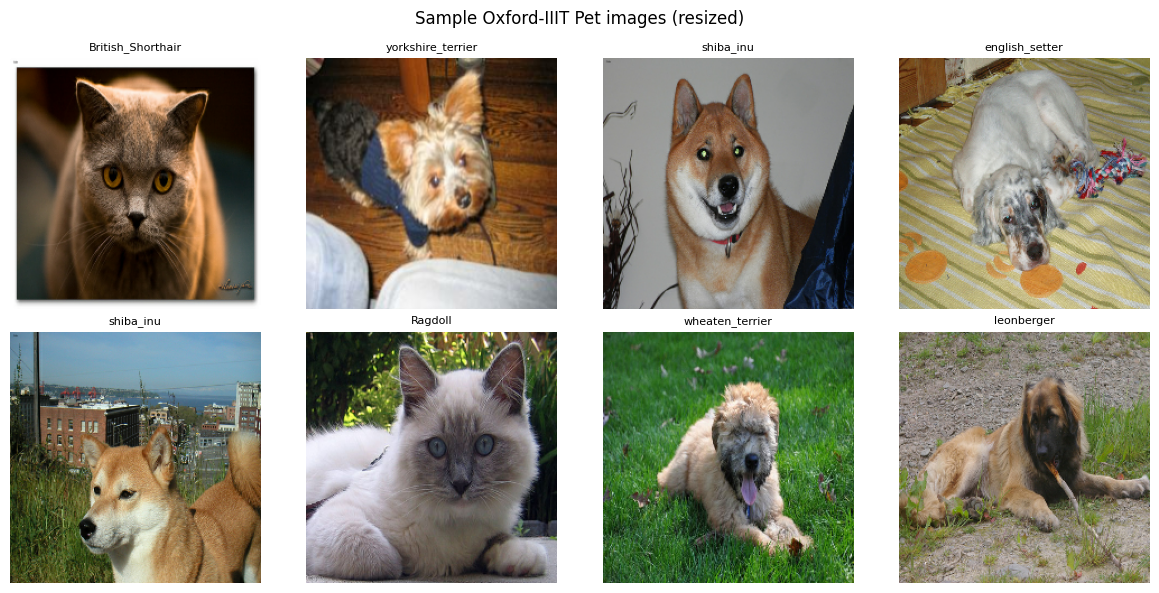

In [20]:
def resize_only(image, label, image_size):
    image = tf.image.resize(image, (image_size, image_size))
    image = tf.cast(image, tf.float32)
    return image, label

def make_eval_dataset(ds, image_size, batch_size):
    ds = ds.map(lambda x, y: resize_only(x, y, image_size), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

eval_preview_ds = make_eval_dataset(train_raw.take(24), cfg['image_size'], batch_size=8)
images, labels = next(iter(eval_preview_ds))

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(tf.cast(images[i], tf.uint8).numpy())
    ax.set_title(class_names[int(labels[i])], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Oxford-IIIT Pet images (resized)')
plt.tight_layout()
plt.show()

## Augmentation Policies

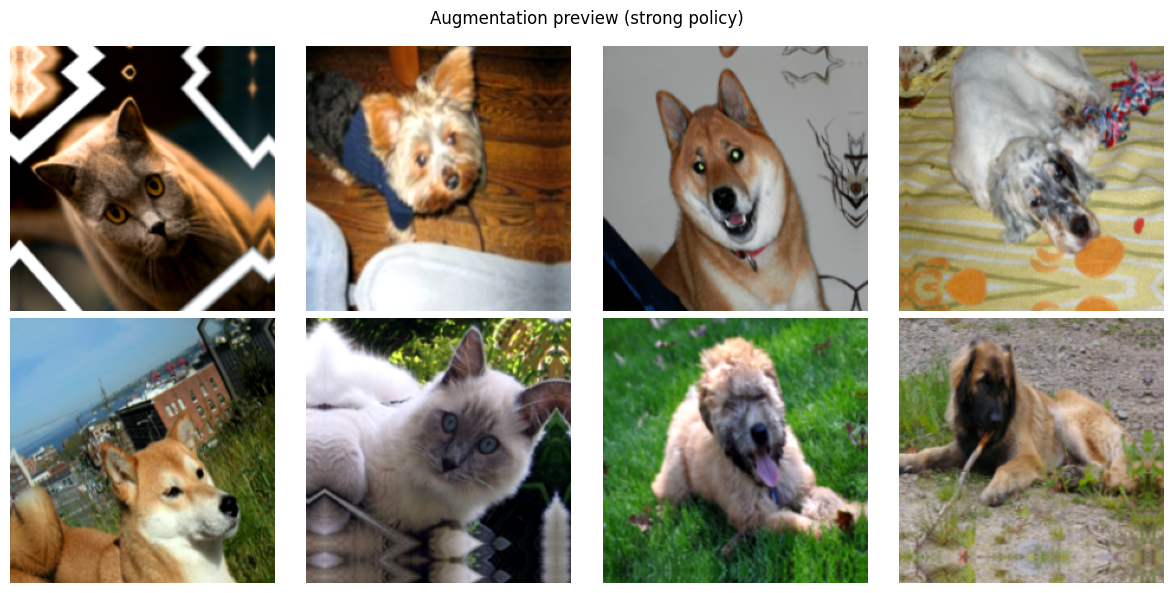

In [21]:
def get_augmentation(policy):
    if policy == 'lite':
        return tf.keras.Sequential([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(0.05),
            tf.keras.layers.RandomZoom(0.10),
        ], name='aug_lite')
    if policy == 'strong':
        return tf.keras.Sequential([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(0.12),
            tf.keras.layers.RandomZoom(0.20),
            tf.keras.layers.RandomContrast(0.20),
            tf.keras.layers.RandomTranslation(0.10, 0.10),
        ], name='aug_strong')
    raise ValueError(f'Unknown policy: {policy}')

aug = get_augmentation('strong')
preview_imgs, _ = next(iter(eval_preview_ds))
aug_imgs = aug(preview_imgs, training=True)

plt.figure(figsize=(12, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(tf.cast(tf.clip_by_value(aug_imgs[i], 0, 255), tf.uint8).numpy())
    ax.axis('off')
plt.suptitle('Augmentation preview (strong policy)')
plt.tight_layout()
plt.show()

## Model Factory and Data Pipeline

In [22]:
BACKBONE_REGISTRY = {
    'MobileNetV2': {
        'model': tf.keras.applications.MobileNetV2,
        'preprocess': tf.keras.applications.mobilenet_v2.preprocess_input
    },
    'ResNet50': {
        'model': tf.keras.applications.ResNet50,
        'preprocess': tf.keras.applications.resnet50.preprocess_input
    },
    'EfficientNetB0': {
        'model': tf.keras.applications.EfficientNetB0,
        'preprocess': tf.keras.applications.efficientnet.preprocess_input
    },
}

def make_dataset(ds, image_size, batch_size, training=False, repeat=False):
    ds = ds.map(lambda x, y: resize_only(x, y, image_size), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(batch_size, drop_remainder=True).prefetch(AUTOTUNE)
    return ds

def build_model(backbone_name, num_classes, image_size, augmentation_policy='lite', dropout=0.35):
    if backbone_name not in BACKBONE_REGISTRY:
        raise ValueError(f'Unsupported backbone: {backbone_name}')

    backbone_cfg = BACKBONE_REGISTRY[backbone_name]
    base_cls = backbone_cfg['model']
    preprocess_fn = backbone_cfg['preprocess']

    inputs = tf.keras.Input(shape=(image_size, image_size, 3), name='image_input')
    x = get_augmentation(augmentation_policy)(inputs)
    x = preprocess_fn(x)

    base_model = base_cls(
        include_top=False,
        weights='imagenet',
        input_shape=(image_size, image_size, 3)
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.Lambda(lambda t: t, name='gradcam_conv')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name=f'{backbone_name}_{augmentation_policy}')
    model.base_model = base_model
    return model

def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5_accuracy')
        ]
    )

## Run Experiment Grid (3 Backbones x 2 Augmentations)

In [23]:
effective_train_count = int(train_counts.sum())
effective_val_count = int(val_counts.sum())
steps_per_epoch = max(1, effective_train_count // cfg['batch_size'])
validation_steps = max(1, effective_val_count // cfg['batch_size'])

print('Effective samples after decode/skip -> train:', effective_train_count, 'val:', effective_val_count)
print('steps_per_epoch:', steps_per_epoch, 'validation_steps:', validation_steps)

train_ds = make_dataset(train_raw, cfg['image_size'], cfg['batch_size'], training=True, repeat=True)
val_ds = make_dataset(val_raw, cfg['image_size'], cfg['batch_size'], training=False, repeat=False)
test_ds = make_dataset(test_raw, cfg['image_size'], cfg['batch_size'], training=False, repeat=False)

run_histories = {}
run_models = {}
run_summaries = []

for backbone in BACKBONES:
    for aug_policy in AUG_POLICIES:
        run_name = f'{backbone}_{aug_policy}'
        print(f'\n===== Running {run_name} =====')

        model = build_model(backbone, num_classes, cfg['image_size'], augmentation_policy=aug_policy)
        compile_model(model, cfg['lr_frozen'])

        ckpt_path = artifacts_dir / f'{run_name}_best_frozen.keras'
        callbacks = [
            tf.keras.callbacks.ModelCheckpoint(str(ckpt_path), monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
            tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max'),
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
        ]

        t0 = time.time()
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=cfg['epochs_frozen'],
            steps_per_epoch=steps_per_epoch,
            validation_steps=validation_steps,
            verbose=1,
            callbacks=callbacks
        )
        elapsed = time.time() - t0

        best_val_acc = float(np.max(history.history['val_accuracy']))
        best_val_top5 = float(np.max(history.history['val_top5_accuracy']))

        run_histories[run_name] = {'frozen': history.history}
        run_models[run_name] = model
        run_summaries.append({
            'run_name': run_name,
            'backbone': backbone,
            'augmentation': aug_policy,
            'best_val_accuracy': best_val_acc,
            'best_val_top5_accuracy': best_val_top5,
            'minutes': elapsed / 60.0
        })

summary_df = pd.DataFrame(run_summaries).sort_values('best_val_accuracy', ascending=False).reset_index(drop=True)
display(summary_df)

Effective samples after decode/skip -> train: 2944 val: 736
steps_per_epoch: 92 validation_steps: 23

===== Running MobileNetV2_lite =====
Epoch 1/12
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3276 - loss: 2.6552 - top5_accuracy: 0.5837
Epoch 1: val_accuracy improved from None to 0.86277, saving model to models/oxford_pet_transfer/MobileNetV2_lite_best_frozen.keras

Epoch 1: finished saving model to models/oxford_pet_transfer/MobileNetV2_lite_best_frozen.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.5598 - loss: 1.6992 - top5_accuracy: 0.8207 - val_accuracy: 0.8628 - val_loss: 0.5599 - val_top5_accuracy: 0.9946 - learning_rate: 0.0010
Epoch 2/12
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8282 - loss: 0.6269 - top5_accuracy: 0.9847
Epoch 2: val_accuracy improved from 0.86277 to 0.88995, saving model to models/oxford_pet_transfer/MobileNetV2_lite_best_frozen.keras

Epoch 2: finished saving model to models/oxford_pet_transfer/MobileNetV2_lite_best_froz

,run_name,backbone,augmentation,best_val_accuracy,best_val_top5_accuracy,minutes
0,EfficientNetB0_lite,EfficientNetB0,lite,0.929348,0.998641,1.366846
1,EfficientNetB0_strong,EfficientNetB0,strong,0.927989,0.997283,1.239448
2,MobileNetV2_lite,MobileNetV2,lite,0.919837,0.997283,0.892643
3,ResNet50_strong,ResNet50,strong,0.910326,1.000000,2.751005
4,MobileNetV2_strong,MobileNetV2,strong,0.907609,0.997283,0.897625
5,ResNet50_lite,ResNet50,lite,0.904891,1.000000,2.640895


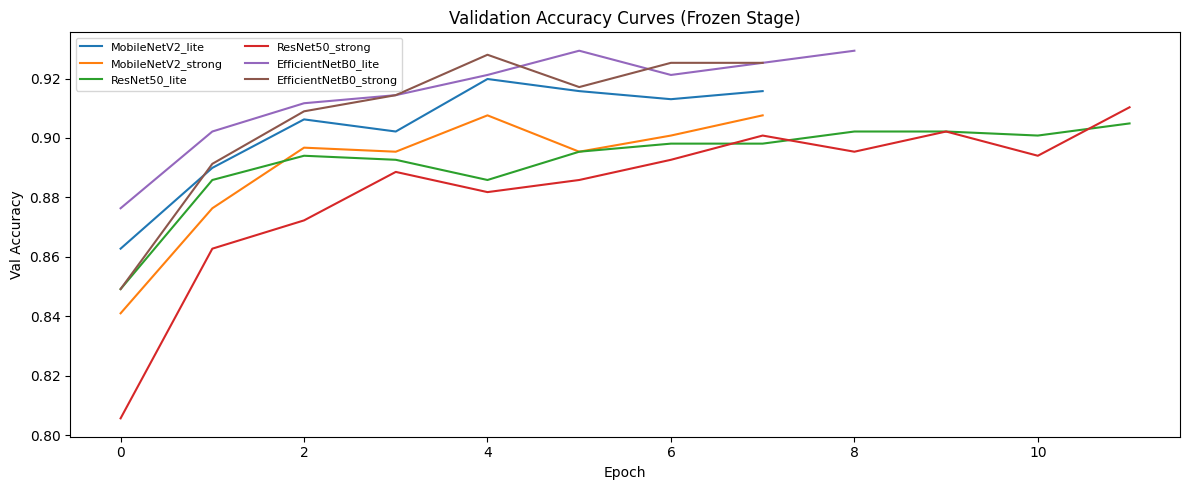

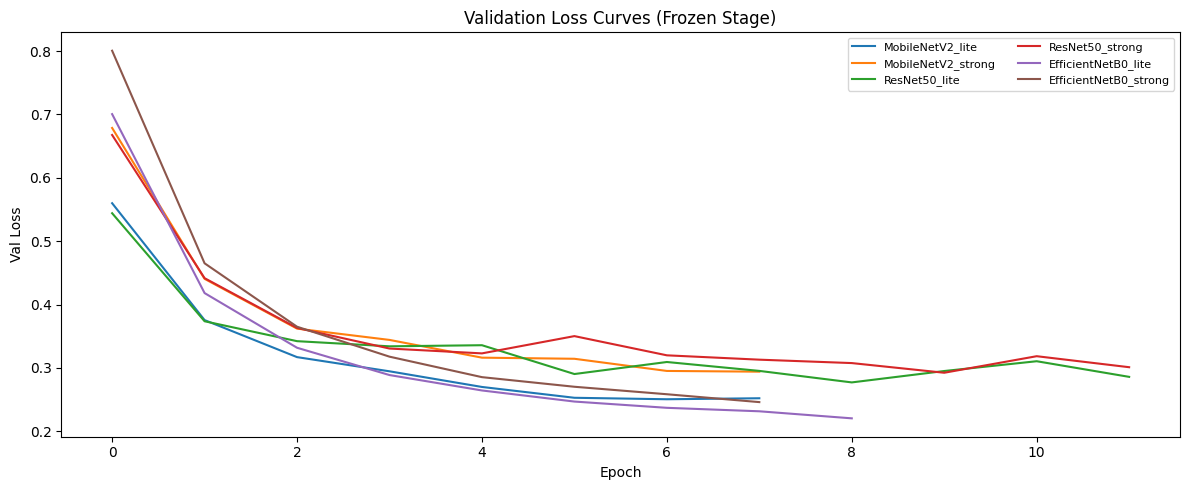

In [24]:
plt.figure(figsize=(12, 5))
for run_name, h in run_histories.items():
    plt.plot(h['frozen']['val_accuracy'], label=f'{run_name}')
plt.title('Validation Accuracy Curves (Frozen Stage)')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for run_name, h in run_histories.items():
    plt.plot(h['frozen']['val_loss'], label=f'{run_name}')
plt.title('Validation Loss Curves (Frozen Stage)')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Fine-Tune Top Run

In [25]:
best_run = summary_df.iloc[0]['run_name']
print('Best frozen run:', best_run)

model = run_models[best_run]
base_model = model.base_model

base_model.trainable = True
for layer in base_model.layers[:-cfg['unfreeze_layers']]:
    layer.trainable = False

trainable_count = np.sum([int(l.trainable) for l in base_model.layers])
print('Trainable layers in backbone after unfreeze:', int(trainable_count), '/', len(base_model.layers))

compile_model(model, cfg['lr_finetune'])

ft_ckpt = artifacts_dir / f'{best_run}_best_finetuned.keras'
ft_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(str(ft_ckpt), monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, mode='max'),
]

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=cfg['epochs_finetune'],
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    verbose=1,
    callbacks=ft_callbacks
)

run_histories[best_run]['finetune'] = history_ft.history
run_models[best_run] = model

Best frozen run: EfficientNetB0_lite
Trainable layers in backbone after unfreeze: 30 / 238
Epoch 1/10


2026-04-19 23:46:01.896960: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_lite_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8501 - loss: 0.7170 - top5_accuracy: 0.9883
Epoch 1: val_accuracy improved from None to 0.90897, saving model to models/oxford_pet_transfer/EfficientNetB0_lite_best_finetuned.keras

Epoch 1: finished saving model to models/oxford_pet_transfer/EfficientNetB0_lite_best_finetuned.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.8478 - loss: 0.6928 - top5_accuracy: 0.9905 - val_accuracy: 0.9090 - val_loss: 0.2987 - val_top5_accuracy: 0.9959
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8519 - loss: 0.6408 - top5_accuracy: 0.9904
Epoch 2: val_accuracy did not improve from 0.90897
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8624 - loss: 0.6127 - top5_accuracy: 0.9922 - val_accuracy: 0.9076 - val_loss: 0.3410 - val_top5_accuracy: 0.9946
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.8810 - loss: 0.5651 - top5_accuracy: 0.9923
Epoch 3: val_accuracy did not improve from 0.90897
92/9

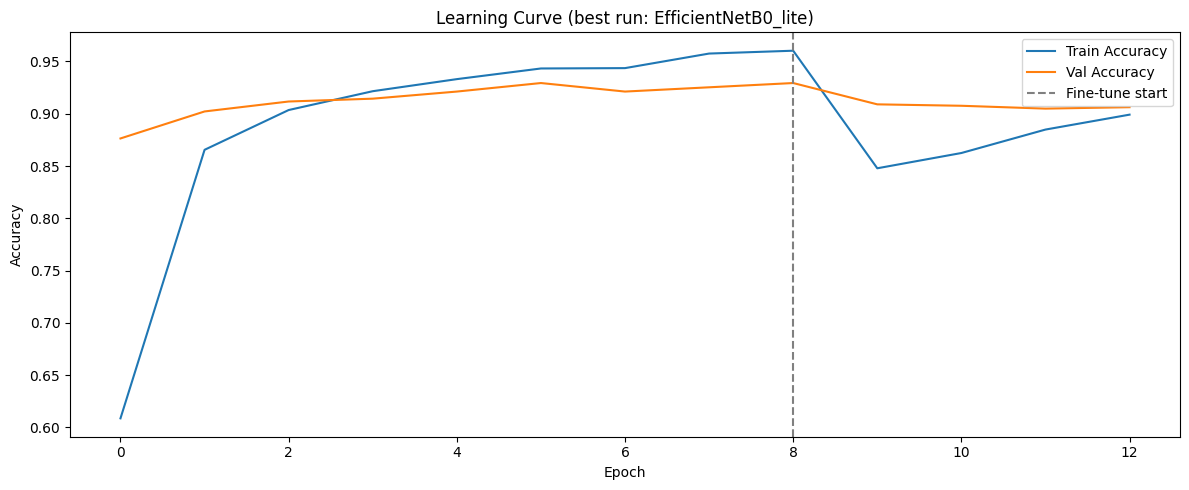

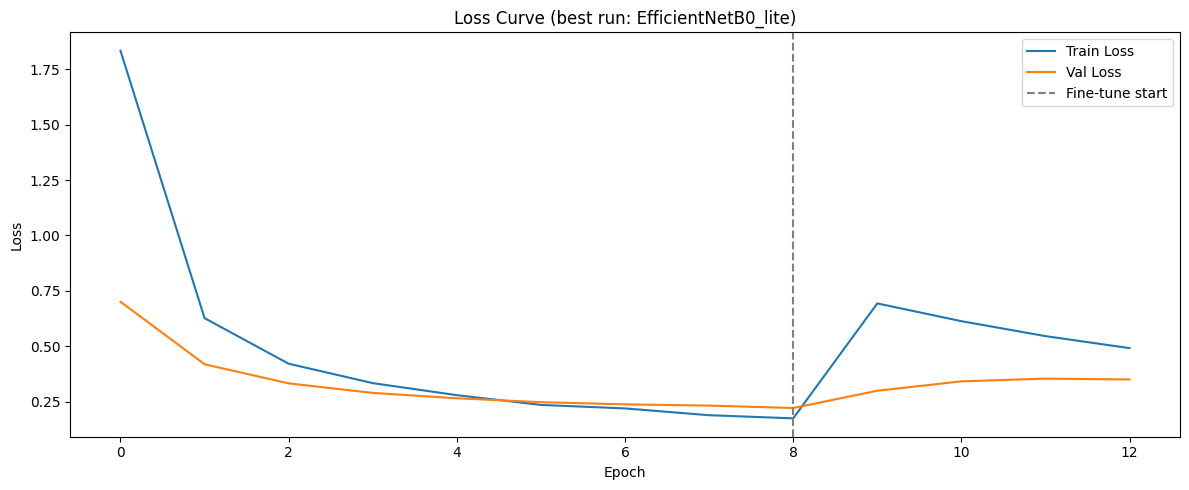

In [26]:
h_f = run_histories[best_run]['frozen']
h_t = run_histories[best_run]['finetune']

acc_curve = h_f['accuracy'] + h_t['accuracy']
val_acc_curve = h_f['val_accuracy'] + h_t['val_accuracy']
loss_curve = h_f['loss'] + h_t['loss']
val_loss_curve = h_f['val_loss'] + h_t['val_loss']

plt.figure(figsize=(12, 5))
plt.plot(acc_curve, label='Train Accuracy')
plt.plot(val_acc_curve, label='Val Accuracy')
plt.axvline(len(h_f['accuracy']) - 1, color='gray', linestyle='--', label='Fine-tune start')
plt.title(f'Learning Curve (best run: {best_run})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(loss_curve, label='Train Loss')
plt.plot(val_loss_curve, label='Val Loss')
plt.axvline(len(h_f['loss']) - 1, color='gray', linestyle='--', label='Fine-tune start')
plt.title(f'Loss Curve (best run: {best_run})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

## Test Evaluation and Diagnostics

114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9000 - loss: 0.3139 - top5_accuracy: 0.9864
{'loss': 0.3138938248157501, 'compile_metrics': 0.8999999761581421}


2026-04-19 23:46:48.242691: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


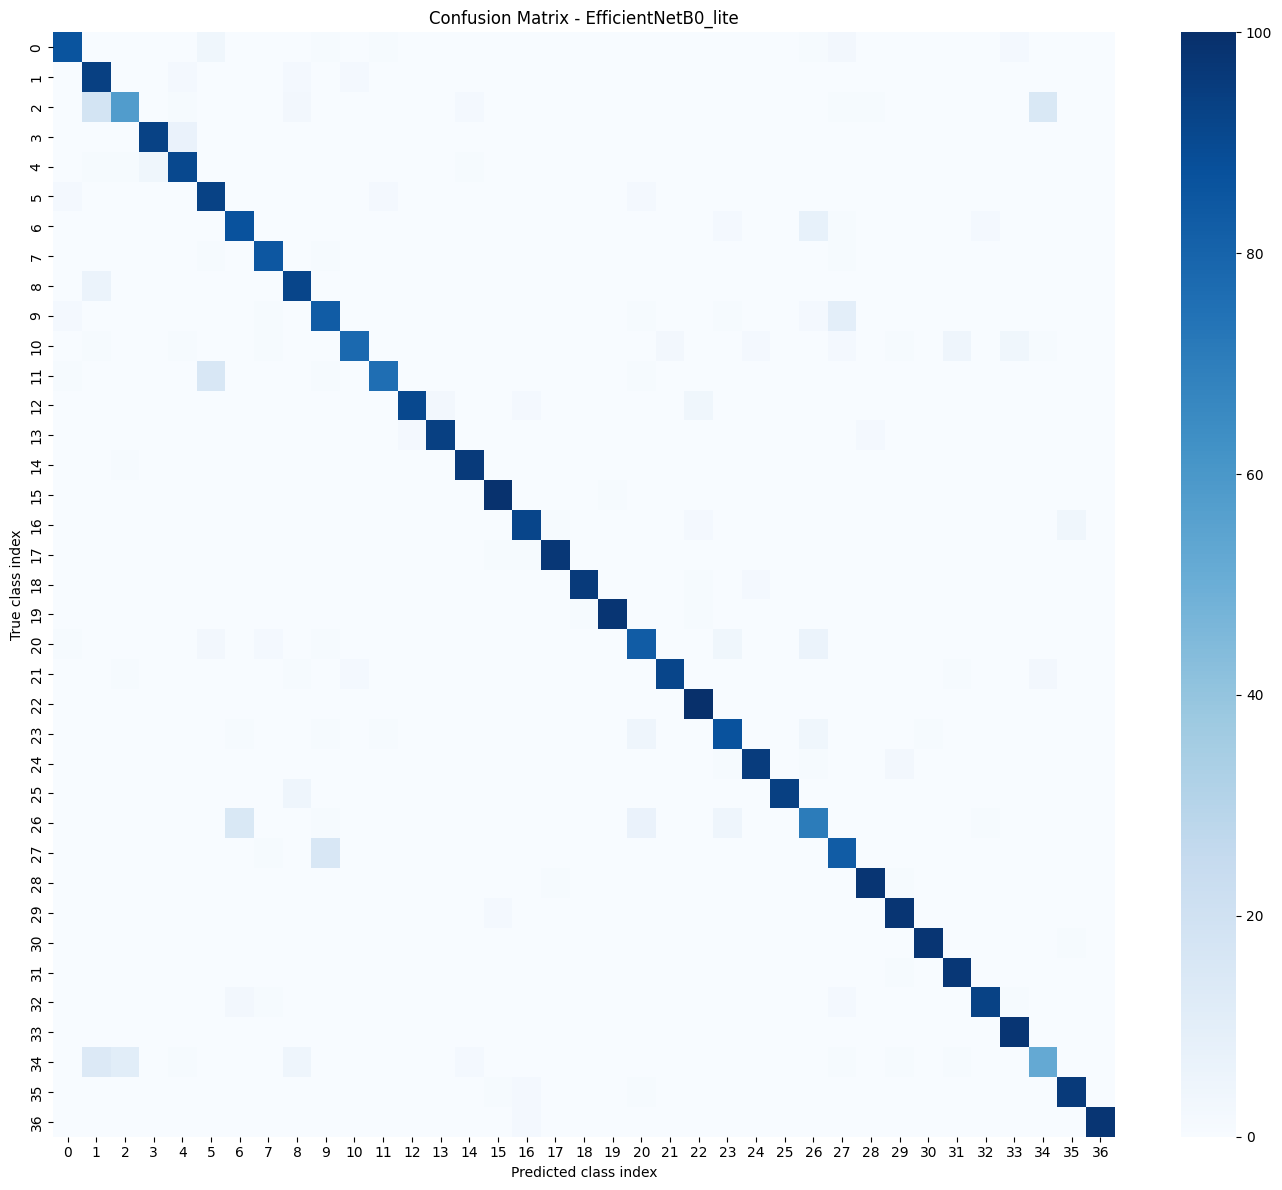

,precision,recall,f1-score,support
Abyssinian,0.934783,0.877551,0.905263,98.0
american_bulldog,0.701493,0.940000,0.803419,100.0
american_pit_bull_terrier,0.805556,0.585859,0.678363,99.0
basset_hound,0.958763,0.930000,0.944162,100.0
beagle,0.883495,0.928571,0.905473,98.0


In [27]:
best_model = run_models[best_run]
test_metrics = best_model.evaluate(test_ds, verbose=1)
print(dict(zip(best_model.metrics_names, test_metrics)))

y_true = []
y_pred = []
y_conf = []

for batch_images, batch_labels in test_ds:
    probs = best_model.predict(batch_images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)

    y_true.extend(batch_labels.numpy().tolist())
    y_pred.extend(preds.tolist())
    y_conf.extend(confs.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_conf = np.array(y_conf)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_run}')
plt.xlabel('Predicted class index')
plt.ylabel('True class index')
plt.tight_layout()
plt.show()

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(num_classes),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
display(report_df.head())

In [28]:
class_metrics = report_df.iloc[:num_classes].copy()
class_metrics['class_name'] = class_metrics.index
class_metrics = class_metrics[['class_name', 'precision', 'recall', 'f1-score', 'support']]
hardest = class_metrics.sort_values(['recall', 'f1-score'], ascending=[True, True]).head(10)

print('10 hardest breeds by recall/f1:')
display(hardest)

mis_idx = np.where(y_true != y_pred)[0]
print('Misclassifications:', len(mis_idx), '/', len(y_true))

10 hardest breeds by recall/f1:


,class_name,precision,recall,f1-score,support
american_pit_bull_terrier,american_pit_bull_terrier,0.805556,0.585859,0.678363,99.0
staffordshire_bull_terrier,staffordshire_bull_terrier,0.732394,0.590909,0.654088,88.0
Ragdoll,Ragdoll,0.763441,0.710000,0.735751,100.0
chihuahua,chihuahua,0.951220,0.787879,0.861878,99.0
Egyptian_Mau,Egyptian_Mau,0.950000,0.800000,0.868571,95.0
British_Shorthair,British_Shorthair,0.790476,0.830000,0.809756,100.0
Russian_Blue,Russian_Blue,0.798077,0.830000,0.813725,100.0
Maine_Coon,Maine_Coon,0.830000,0.830000,0.830000,100.0
Birman,Birman,0.820755,0.870000,0.844660,100.0
Persian,Persian,0.870000,0.870000,0.870000,100.0


Misclassifications: 336 / 3648


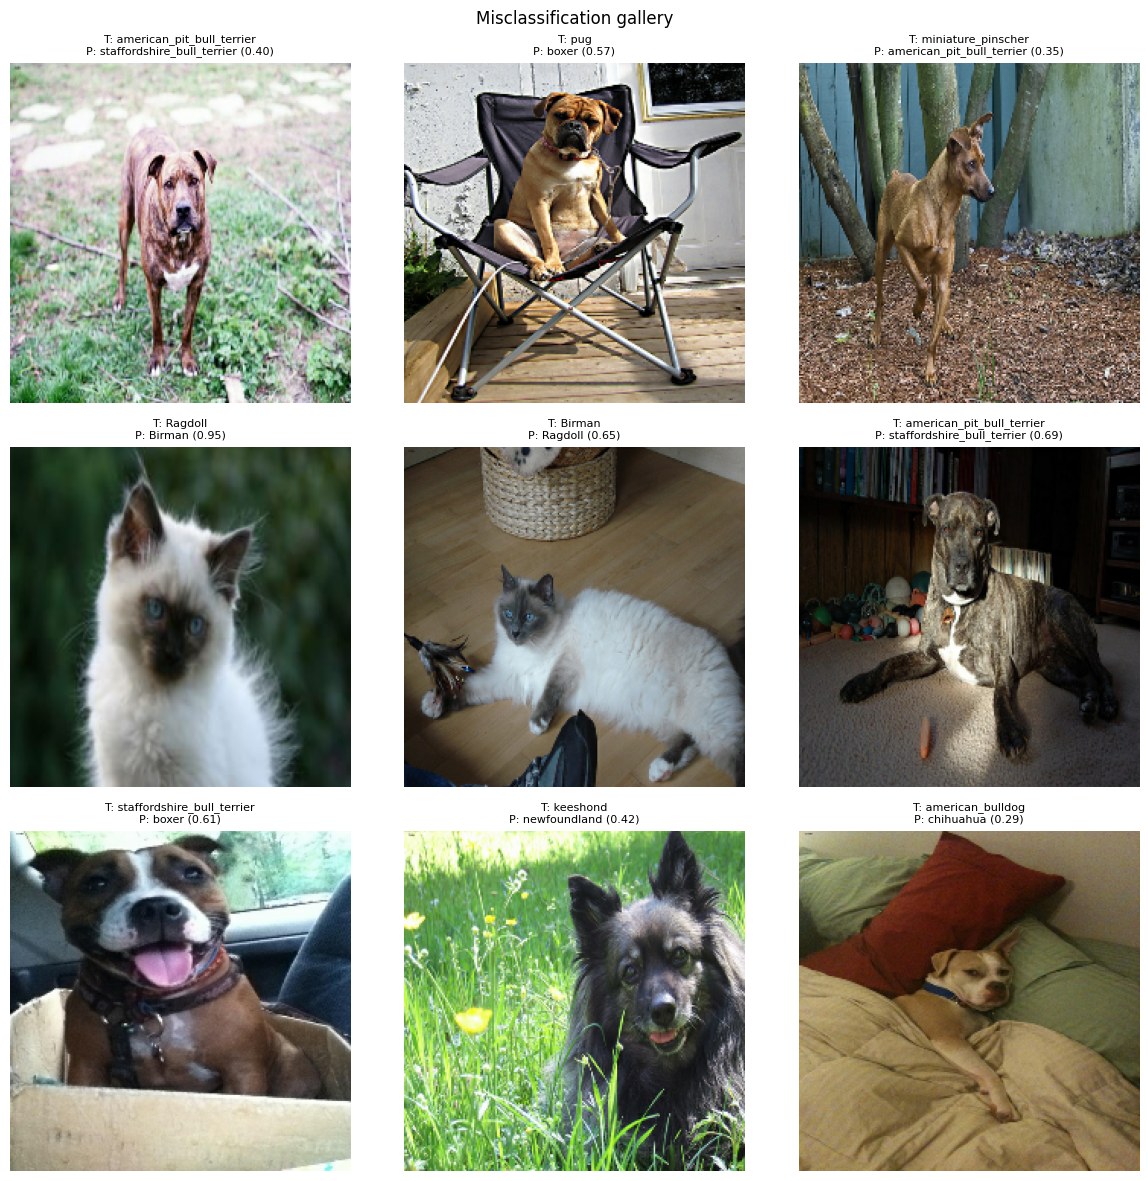

In [29]:
# Build image buffer aligned to y_true/y_pred for error gallery and Grad-CAM
all_images = []
for batch_images, _ in test_ds:
    all_images.append(batch_images.numpy())
all_images = np.concatenate(all_images, axis=0)

if len(mis_idx) > 0:
    n_show = min(9, len(mis_idx))
    chosen = mis_idx[:n_show]

    plt.figure(figsize=(12, 12))
    for i, idx in enumerate(chosen):
        ax = plt.subplot(3, 3, i + 1)
        img = tf.cast(all_images[idx], tf.uint8).numpy()
        ax.imshow(img)
        t = class_names[y_true[idx]]
        p = class_names[y_pred[idx]]
        c = y_conf[idx]
        ax.set_title(f'T: {t}\nP: {p} ({c:.2f})', fontsize=8)
        ax.axis('off')
    plt.suptitle('Misclassification gallery')
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications found in test set for current run.')

## Grad-CAM on Misclassified Examples

/home/berimbolo/agh/6sem/ml/.venv/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image_input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
W0000 00:00:1776635235.712670    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776635235.714205    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776635235.715191    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776635235.716152    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776635235.717019    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1776635235.717979    5299 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:

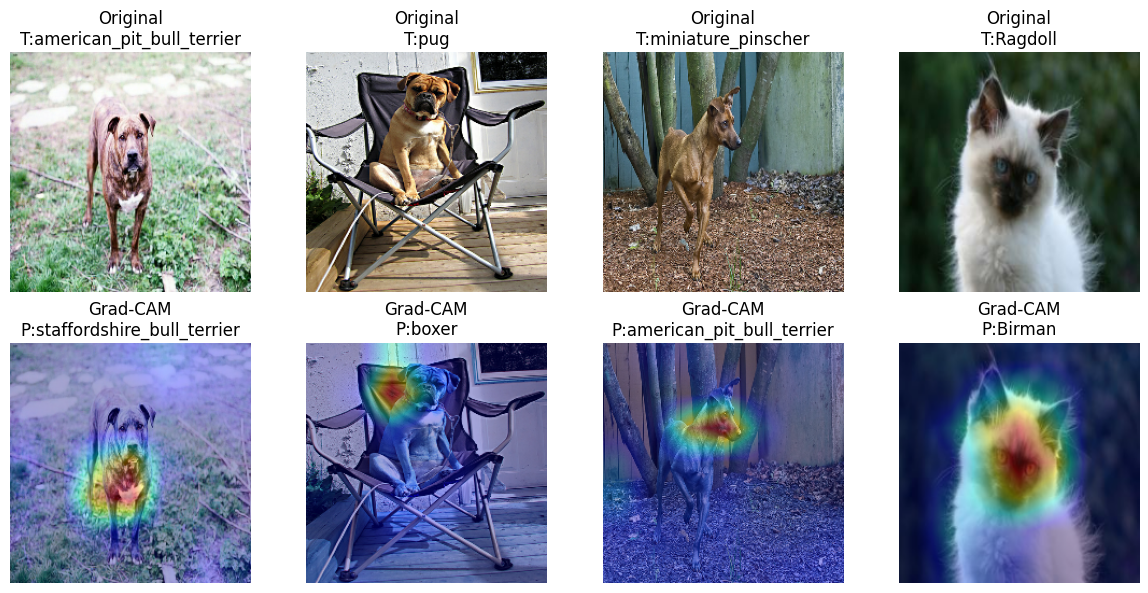

In [30]:
def make_gradcam_heatmap(model, image_tensor, pred_index=None):

    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer('gradcam_conv').output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(image_tensor)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    denom = tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap / denom
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.35):
    img_uint8 = img.astype(np.uint8)
    heatmap_resized = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_uint8, 1 - alpha, colored, alpha, 0)
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

if len(mis_idx) > 0:
    n_cam = min(4, len(mis_idx))
    selected = mis_idx[:n_cam]

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(selected):
        raw_img = all_images[idx]
        inp = np.expand_dims(raw_img, axis=0).astype(np.float32)
        heat = make_gradcam_heatmap(best_model, inp, pred_index=y_pred[idx])
        cam = overlay_heatmap(raw_img, heat)

        ax = plt.subplot(2, n_cam, i + 1)
        ax.imshow(raw_img.astype(np.uint8))
        ax.set_title(f'Original\nT:{class_names[y_true[idx]]}')
        ax.axis('off')

        ax2 = plt.subplot(2, n_cam, i + 1 + n_cam)
        ax2.imshow(cam)
        ax2.set_title(f'Grad-CAM\nP:{class_names[y_pred[idx]]}')
        ax2.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Skipping Grad-CAM because there are no misclassifications.')